In [1]:
from astropy.io import fits
import healpy as hp
import numpy as np
nside = 1024

ldir = '/mnt/ceph/users/spandey/GODMAX/notebooks/all_arxiv/mock_gen/sdss_data'

dfg = fits.open(f'{ldir}/galaxy_DR12v5_CMASS_North.fits.gz')
ra_g1, dec_g1, z_g1 = dfg[1].data['RA'], dfg[1].data['DEC'], dfg[1].data['Z']
w_g1 = dfg[1].data['WEIGHT_SYSTOT']

dfg = fits.open(f'{ldir}/galaxy_DR12v5_CMASS_South.fits.gz')
ra_g2, dec_g2, z_g2 = dfg[1].data['RA'], dfg[1].data['DEC'], dfg[1].data['Z']
w_g2 = dfg[1].data['WEIGHT_SYSTOT']

z_g = np.concatenate((z_g1, z_g2))
zmin = 0.4
zmax = 0.8
indsel = np.where((z_g > zmin) & (z_g < zmax))[0]

z_g = z_g[indsel]
ra_g = np.concatenate((ra_g1, ra_g2))[indsel]
dec_g = np.concatenate((dec_g1, dec_g2))[indsel]
w_g = np.concatenate((w_g1, w_g2))[indsel]


z_array = np.linspace(0, 1.5, 200)
z_centers = 0.5 * (z_array[1:] + z_array[:-1])

hist_z = np.histogram(z_g, bins=z_array, density=True)[0]

# print(dfg[1].header)




In [2]:
df = fits.open(f'{ldir}/random1_DR12v5_CMASS_South.fits.gz')
ra_rand1, dec_rand1, z_rand1 = df[1].data['RA'], df[1].data['DEC'], df[1].data['Z']
w_rand1 = np.ones_like(ra_rand1)


df = fits.open(f'{ldir}/random1_DR12v5_CMASS_North.fits.gz')
ra_rand2, dec_rand2, z_rand2 = df[1].data['RA'], df[1].data['DEC'], df[1].data['Z']
w_rand2 = np.ones_like(ra_rand2)

ra_rand = np.concatenate((ra_rand1, ra_rand2))
dec_rand = np.concatenate((dec_rand1, dec_rand2))
z_rand = np.concatenate((z_rand1, z_rand2))
w_rand = np.concatenate((w_rand1, w_rand2))






In [3]:
# import pymaster as nmt
ipix = hp.ang2pix(nside, ra_g, dec_g, lonlat=True)
npix = hp.nside2npix(nside)

nmap = np.bincount(ipix, minlength=npix, weights=w_g)

ipix_rand = hp.ang2pix(nside, ra_rand, dec_rand, lonlat=True)
npix_rand = hp.nside2npix(nside)

nmap_rand = np.bincount(ipix_rand, minlength=npix_rand)



In [4]:
# mask = hp.ud_grade(np., nside_out=nside)
mask = np.clip(nmap_rand, 0, 1)
nbar = np.sum(nmap)/np.sum(mask)
nbar_map = nbar * mask
# Avoid division by zero below
good = mask > 0
delta = np.zeros(npix)
delta[good] = nmap[good]/nbar_map[good]-1

not_good = mask == 0
delta[not_good] = hp.UNSEEN

# # Now create a NaMaster field
# f_pix = nmt.NmtField(mask, [delta], n_iter=0)

# wpix = nmt.NmtWorkspace.from_fields(f_pix, f_pix, b)

# pcl = nmt.compute_coupled_cell(f_pix, f_pix)
# cl = wpix.decouple_cell(pcl)

# pnl = 4*np.pi*np.mean(mask)/(npix*nbar)
# nl = wpix.decouple_cell(pnl*np.ones_like(pcl))

# cl_pix = cl-nl




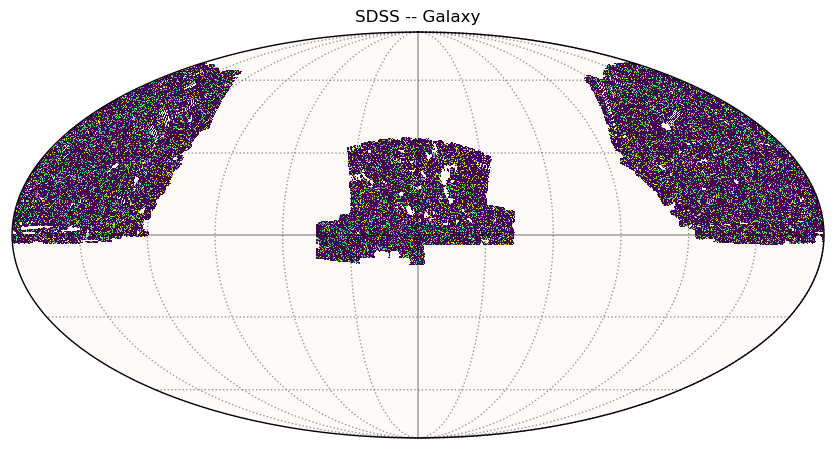

In [50]:
hp.mollview(delta, min=-1, max=4, badcolor='snow', title='SDSS -- Galaxy', cbar=False)
hp.graticule(alpha=0.4)





In [6]:
df = hp.read_map('/mnt/ceph/users/spandey/GODMAX/data/NILC_ymap_rotated_celestial_DES_coords.fits')
ymap_data_planck = hp.ud_grade(df, nside_out=nside)





In [7]:
from pixell import enmap, enplot, utils, curvedsky, reproject
ldir_y = '/mnt/ceph/users/spandey/xdesi/act/tsz/cib_cibdBeta'
ymap = enmap.read_map(f"{ldir_y}/ilc_actplanck_ymap_deproj_cib_cibdBeta_1.7_10.7.fits") #downgraded map
ymap = enmap.downgrade(ymap,2)

NSIDE = nside
ELLMAX = 2*NSIDE
ymap_hp_ACT = reproject.map2healpix(ymap, nside=NSIDE, lmax=ELLMAX)


In [8]:


ymask = enmap.read_map(f"{ldir_y}/wide_mask_GAL080_apod_1.50_deg_wExtended.fits")
ymask = enmap.downgrade(ymask,2)

ymask_hp_ACT = reproject.map2healpix(ymask, nside=NSIDE//4, lmax=ELLMAX//4)





In [9]:
def find_mask_edges_fast(mask, nside=None, n_neighbor_layers=1):
    """
    Find edge pixels of a HEALPix mask with adjustable thickness.
    
    Parameters:
    -----------
    mask : array
        HEALPix mask array (1 for masked, 0 for unmasked)
    nside : int, optional
        HEALPix NSIDE parameter. If None, inferred from mask length.
    n_neighbor_layers : int, optional
        Number of neighbor layers to include in edges (default: 1)
        
    Returns:
    --------
    edges : array
        Array with 1 at edge pixels, 0 elsewhere
    """
    if nside is None:
        nside = hp.npix2nside(len(mask))
    
    edges = np.zeros_like(mask)
    
    # Start with pixels that are masked
    masked_pixels = np.where(mask > 0.5)[0]
    
    # Find immediate edge pixels
    for ipix in masked_pixels:
        neighbors = hp.get_all_neighbours(nside, ipix)
        valid_neighbors = neighbors[neighbors != -1]
        
        if len(valid_neighbors) > 0:
            neighbor_vals = mask[valid_neighbors]
            # If any neighbor is unmasked, this is an edge
            if np.any(neighbor_vals < 0.5):
                edges[ipix] = 1
    
    # Expand edges by adding neighbor layers
    if n_neighbor_layers > 1:
        for layer in range(n_neighbor_layers - 1):
            new_edges = edges.copy()
            edge_pixels = np.where(edges > 0.5)[0]
            
            for ipix in edge_pixels:
                neighbors = hp.get_all_neighbours(nside, ipix)
                valid_neighbors = neighbors[neighbors != -1]
                
                # Mark all masked neighbors of edge pixels as edges
                for neighbor in valid_neighbors:
                    if mask[neighbor] > 0.5:  # only expand within mask
                        new_edges[neighbor] = 1
            
            edges = new_edges
    
    return edges

# Now you can call it without specifying nside:
edges_thick = find_mask_edges_fast(ymask_hp_ACT, n_neighbor_layers=8)


# edges_ACT = find_mask_edges_fast(ymask_hp_ACT, nside)


In [10]:
from tqdm import tqdm
def fill_mask_holes(mask, nside=None, method='closing', n_iterations=2):
    """
    Fill holes in a HEALPix mask using morphological operations.
    
    Parameters:
    -----------
    mask : array
        HEALPix mask array (1 for masked, 0 for unmasked)
    nside : int, optional
        HEALPix NSIDE parameter. If None, inferred from mask length.
    method : str, optional
        'closing' - morphological closing (dilation then erosion)
        'flood' - flood fill from edges (fills isolated holes)
    n_iterations : int, optional
        Number of dilation/erosion iterations for 'closing' method (default: 2)
        
    Returns:
    --------
    filled_mask : array
        Mask with holes filled
    """
    if nside is None:
        nside = hp.npix2nside(len(mask))
    
    if method == 'closing':
        # Morphological closing: dilate then erode
        filled_mask = mask.copy()
        
        # Dilation step (expand mask)
        for _ in tqdm(range(n_iterations)):
            new_mask = filled_mask.copy()
            masked_pixels = np.where(filled_mask > 0.5)[0]
            
            for ipix in masked_pixels:
                neighbors = hp.get_all_neighbours(nside, ipix)
                valid_neighbors = neighbors[neighbors != -1]
                new_mask[valid_neighbors] = 1
            
            filled_mask = new_mask
        
        # Erosion step (shrink mask back)
        for _ in tqdm(range(n_iterations)):
            new_mask = filled_mask.copy()
            masked_pixels = np.where(filled_mask > 0.5)[0]
            
            for ipix in masked_pixels:
                neighbors = hp.get_all_neighbours(nside, ipix)
                valid_neighbors = neighbors[neighbors != -1]
                neighbor_vals = filled_mask[valid_neighbors]
                
                # If any neighbor is unmasked, unmask this pixel
                if np.any(neighbor_vals < 0.5):
                    new_mask[ipix] = 0
            
            filled_mask = new_mask
            
    elif method == 'flood':
        # Flood fill from boundary to identify and fill holes
        filled_mask = mask.copy()
        npix = len(mask)
        
        # Start flood fill from unmasked pixels
        outside = np.zeros(npix, dtype=bool)
        unmasked = mask < 0.5
        
        # Initialize with boundary pixels (pixels at theta=0 and theta=pi)
        theta, phi = hp.pix2ang(nside, np.arange(npix))
        # Start from pixels near poles as boundary
        boundary_threshold = 0.1  # radians from poles
        is_boundary = (theta < boundary_threshold) | (theta > (np.pi - boundary_threshold))
        outside[unmasked & is_boundary] = True
        
        # Flood fill to find all outside regions
        max_iter = npix  # safety limit
        for iteration in range(max_iter):
            outside_pixels = np.where(outside)[0]
            print(iteration, len(outside_pixels))
            new_outside_found = False
            
            for ipix in outside_pixels:
                neighbors = hp.get_all_neighbours(nside, ipix)
                valid_neighbors = neighbors[neighbors != -1]
                
                # Expand to unmasked neighbors
                for neighbor in valid_neighbors:
                    if unmasked[neighbor] and not outside[neighbor]:
                        outside[neighbor] = True
                        new_outside_found = True
            
            if not new_outside_found:
                break
        
        # Fill holes: unmasked pixels that aren't outside are holes
        holes = unmasked & ~outside
        filled_mask[holes] = 1
    
    return filled_mask


# Usage:
# Fill small holes using morphological closing (recommended - fast and reliable)





In [11]:
ymask_filled = fill_mask_holes(ymask_hp_ACT, method='closing', n_iterations=10)



  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:39<00:00,  3.95s/it]


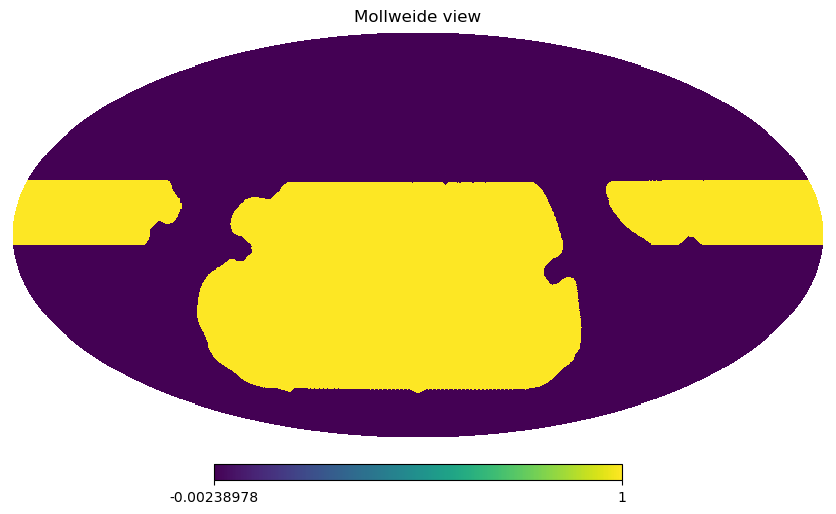

In [12]:
hp.mollview(ymask_filled)



In [13]:
ymask_filled_ud = hp.ud_grade(ymask_filled, nside_out=nside)


In [14]:
# Then find edges
edges = find_mask_edges_fast(ymask_filled, n_neighbor_layers=6)

edges_ud = hp.ud_grade(edges, nside_out=nside)


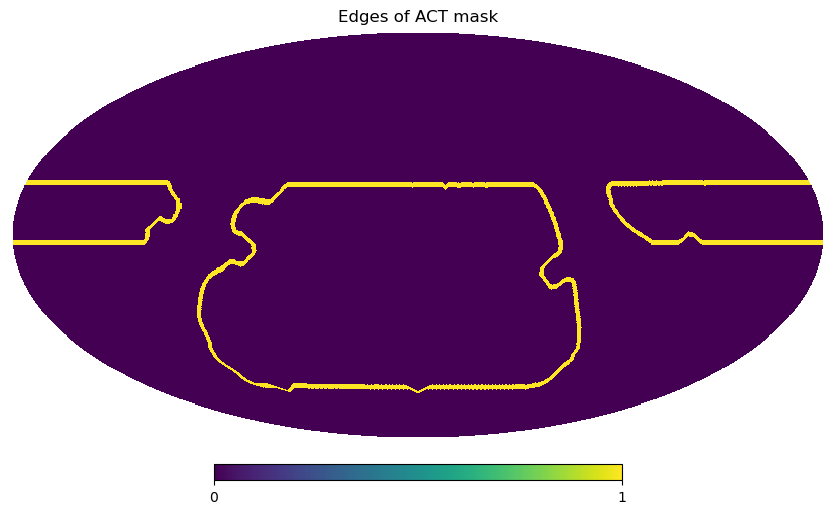

In [15]:
hp.mollview(edges_ud, title='Edges of ACT mask')



In [16]:
ymap_total = ymap_data_planck.copy()
ymap_total[ymask_filled_ud==1] = ymap_hp_ACT[ymask_filled_ud==1]
ymap_total[edges_ud==1] = hp.UNSEEN


In [17]:
# find the edges of the ACT mask:


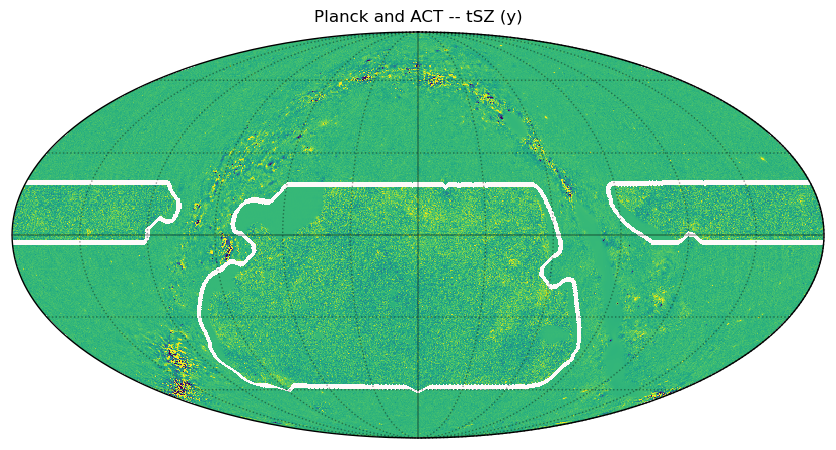

In [48]:
hp.mollview(ymap_total, min=-4e-5, max=2e-5, badcolor='snow', title='Planck and ACT -- tSZ (y)', cbar=False)
hp.graticule(alpha=0.4)


In [19]:
ldir_pl_lensing = '/mnt/ceph/users/spandey/GODMAX/data/PR4_variations/'
klm_pr4 = hp.read_alm(f'{ldir_pl_lensing}/PR42018like_klm_mf_MV.fits')
klm_pr4_rotated = hp.Rotator(coord=['G','C']).rotate_alm(klm_pr4)
map_pr4 = hp.alm2map(klm_pr4_rotated, nside=nside, lmax=2*nside)




In [20]:
mask_klm = hp.read_map(f'{ldir_pl_lensing}/mask.fits.gz')
mask_klm = hp.Rotator(coord=['G','C']).rotate_map_pixel(mask_klm)
mask_klm = hp.ud_grade(mask_klm, nside_out=nside)


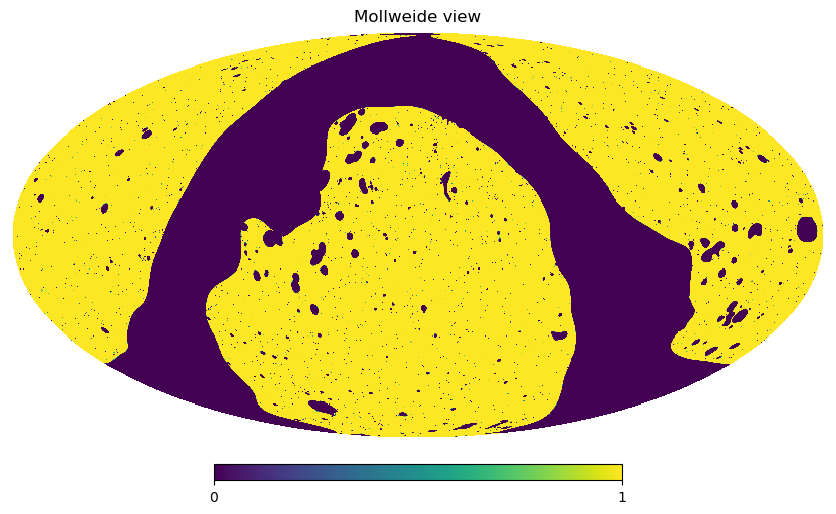

In [21]:
hp.mollview(mask_klm)



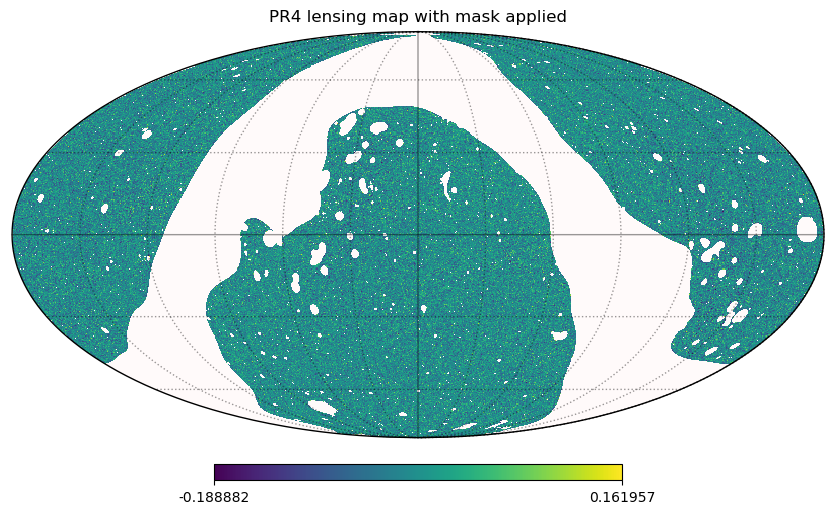

In [22]:
map_pr4_masked = map_pr4.copy()
map_pr4_masked[mask_klm==0] = hp.UNSEEN
hp.mollview(map_pr4_masked, badcolor='snow', title='PR4 lensing map with mask applied')
hp.graticule(alpha=0.4)



In [23]:
ldir_lensing = '/mnt/ceph/users/spandey/xdesi/act/lensing/baseline'
alms = f'{ldir_lensing}/kappa_alm_data_act_dr6_lensing_v1_baseline.fits'

kappa = hp.read_alm(f'{ldir_lensing}/kappa_alm_data_act_dr6_lensing_v1_baseline.fits')
kappa = np.nan_to_num(kappa)
map_kappa = hp.alm2map(kappa.astype(np.complex128), nside)
from pixell import enmap, enplot, reproject, curvedsky as cs,utils
mask = hp.read_map(f'{ldir_lensing}/mask_act_dr6_lensing_v1_healpix_nside_4096_baseline.fits')
mask = hp.ud_grade(mask, nside_out=nside)

In [24]:
map_pr4_masked_wACT = map_pr4_masked.copy()
map_pr4_masked_wACT[mask==1] = map_kappa[mask==1]



In [25]:
# Then find edges
mask_dg = hp.ud_grade(mask, nside_out=nside//4)
edges_kappa = find_mask_edges_fast(mask_dg, n_neighbor_layers=6)
edges_ud_kappa = hp.ud_grade(edges_kappa, nside_out=nside)


In [26]:
map_pr4_masked_wACT[edges_ud_kappa==1] = hp.UNSEEN



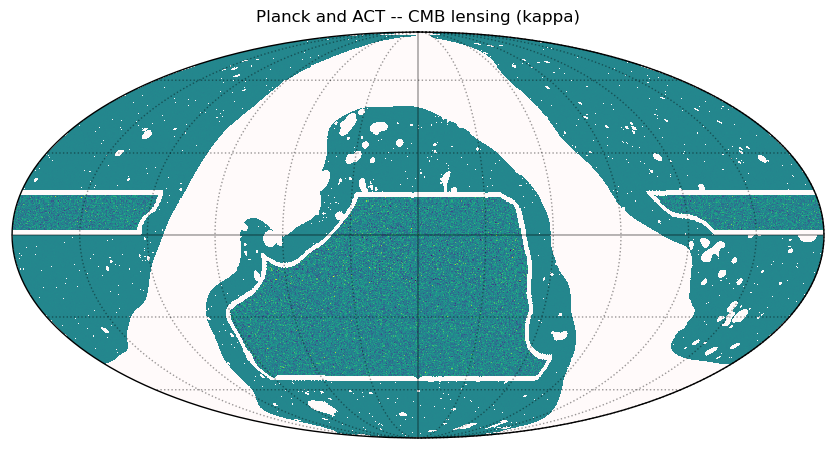

In [46]:
hp.mollview(map_pr4_masked_wACT, badcolor='snow', title='Planck and ACT -- CMB lensing (kappa)', cbar=False)
hp.graticule(alpha=0.4)



In [28]:
from pixell import enmap, enplot, utils, curvedsky, reproject
ldir_ksz = '/mnt/ceph/users/spandey/xdesi/act/ksz'

ksz_map = enmap.read_map(f"{ldir_ksz}/act-planck_dr6.02_nilc_blackbody_T.fits") #downgraded map
ksz_map = enmap.downgrade(ksz_map,2)

NSIDE = nside
ELLMAX = 2*NSIDE
ksz_map_hp_ACT = reproject.map2healpix(ksz_map, nside=NSIDE, lmax=ELLMAX)



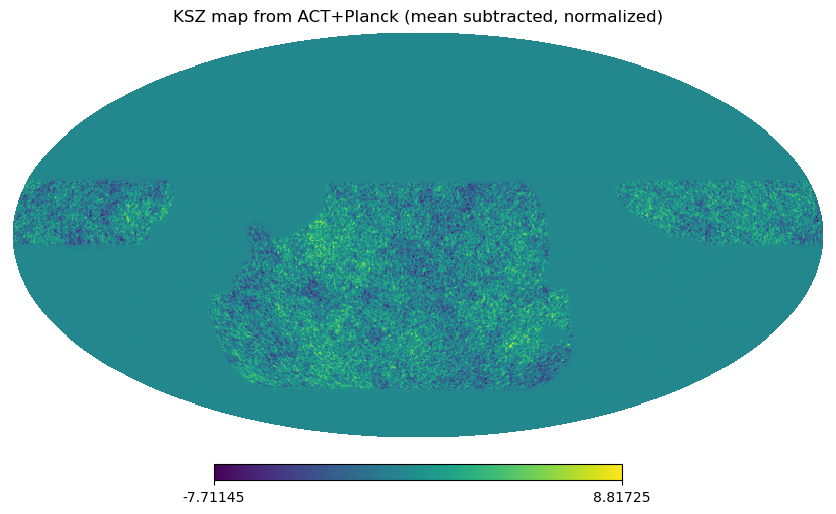

In [29]:
hp.mollview((ksz_map_hp_ACT - np.mean(ksz_map_hp_ACT))/np.std(ksz_map_hp_ACT), title='KSZ map from ACT+Planck (mean subtracted, normalized)')



In [30]:
df = hp.read_map('/mnt/ceph/users/spandey/GODMAX/data/COM_CMB_IQU-nilc_2048_R3.00_full.fits')
ksz_data_planck = hp.ud_grade(df, nside_out=nside)





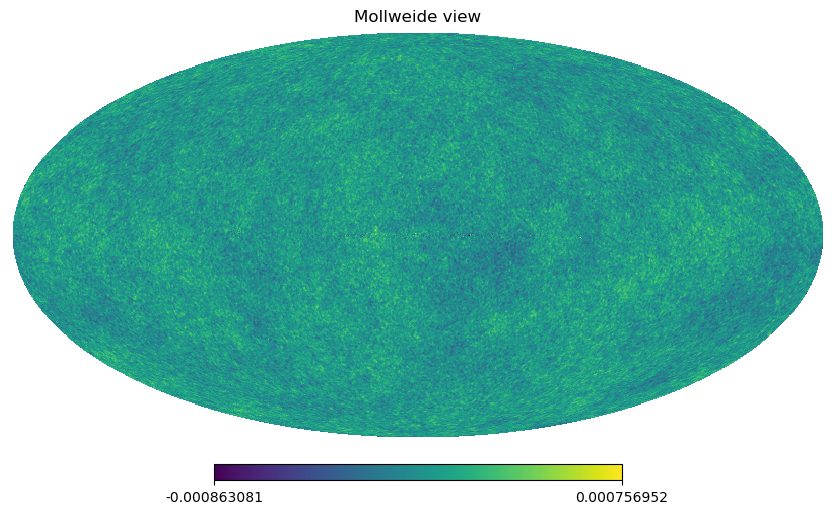

In [31]:
hp.mollview(ksz_data_planck)




In [32]:
kszmap_total = ksz_data_planck.copy()
kszmap_total[mask==1] = ksz_map_hp_ACT[mask==1]/7e5
kszmap_total[edges_ud_kappa==1] = hp.UNSEEN



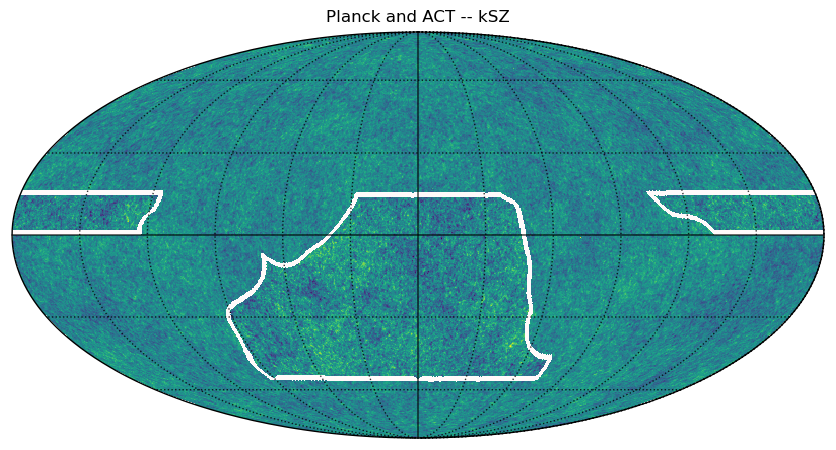

In [42]:
hp.mollview(kszmap_total, badcolor='snow', title='Planck and ACT -- kSZ', cbar=False)
hp.graticule(alpha=0.8)


In [34]:
ldir_des = '/mnt/ceph/users/spandey/xdesi/des/kappa_WL'
# kappa_des = hp.ud_grade(hp.read_map(f'{ldir_des}/nullB_tomo4.fits'), nside)
kappa_des = hp.ud_grade(hp.read_map(f'{ldir_des}/KS_tomo4.fits'), nside)
mask_des = hp.ud_grade(hp.read_map(f'{ldir_des}/glimpse_mask.fits'), nside)




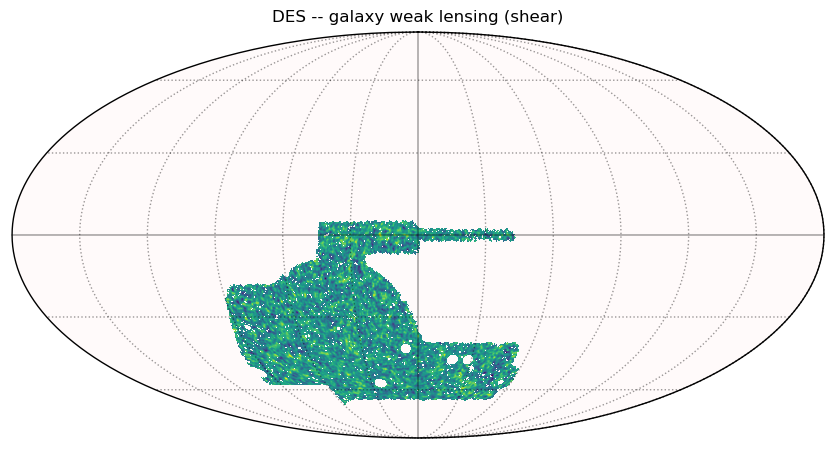

In [45]:
kappa_des_masked = kappa_des.copy()
kappa_des_masked[mask_des==0] = hp.UNSEEN
hp.mollview(kappa_des_masked, badcolor='snow', title='DES -- galaxy weak lensing (shear)', cbar=False)
hp.graticule(alpha=0.4)
